In [ ]:
import os

print("Train file size:", os.path.getsize("train.zip"))
print("Test file size:", os.path.getsize("test1.zip"))

Train file size: 569546721
Test file size: 284321224


In [ ]:
import zipfile

with zipfile.ZipFile("train.zip", "r") as zip_ref:
    zip_ref.extractall("train_data")

print("Train dataset extracted successfully!")

Train dataset extracted successfully!


In [ ]:
with zipfile.ZipFile("test1.zip", "r") as zip_ref:
    zip_ref.extractall("test_data")

print("Test dataset extracted successfully!")

Test dataset extracted successfully!


In [ ]:
import os

print(os.listdir("train_data/train")[:10])

['cat.5950.jpg', 'dog.3324.jpg', 'cat.12293.jpg', 'cat.10991.jpg', 'dog.1705.jpg', 'cat.3047.jpg', 'cat.854.jpg', 'cat.9627.jpg', 'dog.2549.jpg', 'cat.7631.jpg']


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from skimage.io import imread
from skimage.transform import resize


In [ ]:
images = []
labels = []

folder = "train_data/train"

files = os.listdir(folder)

files = files[:1000]

print("Total images selected:", len(files))

Total images selected: 1000


In [ ]:
for file in files:

    img_path = os.path.join(folder, file)

    img = imread(img_path)

    img = resize(img, (64, 64))

    images.append(img.flatten())

    if file.startswith("cat"):
        labels.append(0)

    else:
        labels.append(1)

In [ ]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(1000, 12288)
(1000,)


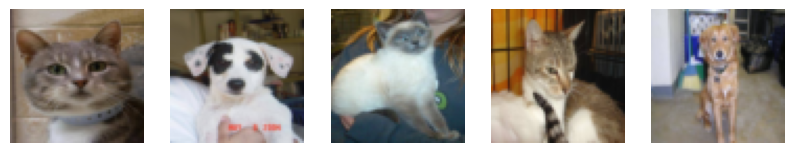

In [ ]:
plt.figure(figsize=(10,5))

for i in range(5):

    plt.subplot(1,5,i+1)

    img = X[i].reshape(64,64,3)

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 12288)
Testing Data: (200, 12288)


In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

model.fit(X_train, y_train)

print("Model Training Complete!")

Model Training Complete!


In [ ]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 0 1 0 0 0 0 1 1 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.55


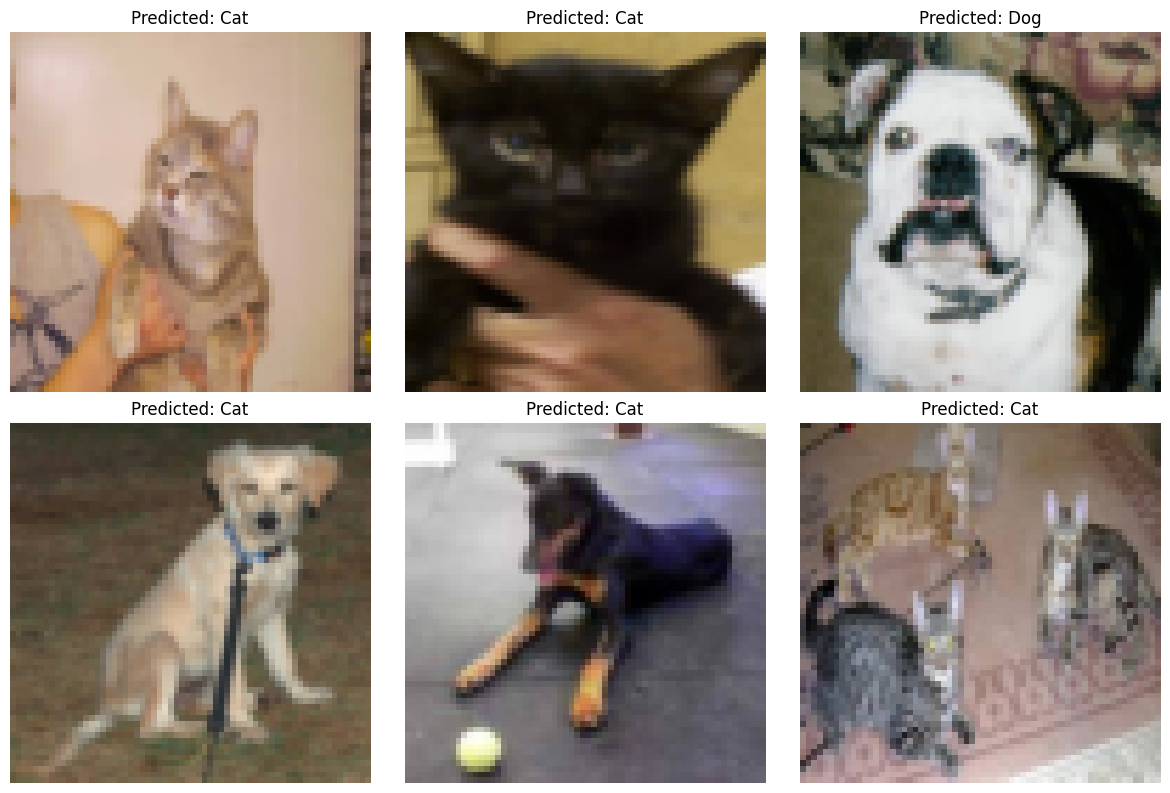

In [ ]:
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i].reshape(64,64,3))

    plt.title(
        f"Predicted: {'Dog' if predictions[i]==1 else 'Cat'}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Task 3 Accuracy:", accuracy)

Task 3 Accuracy: 0.55
